# Working Code

          timestamp  meter_reading  \
0  01/11/2023 00:00          0.000   
1  01/11/2023 01:00          0.000   
2  01/11/2023 02:00          0.000   
3  01/11/2023 03:00          0.000   
4  01/11/2023 04:00          0.000   
5  01/11/2023 05:00          0.000   
6  01/11/2023 06:00          0.625   
7  01/11/2023 07:00          8.250   
8  01/11/2023 08:00         34.250   
9  01/11/2023 09:00         65.000   

                                             meter  
0  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
1  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
2  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
3  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
4  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
5  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
6  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
7  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
8  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  
9  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh 

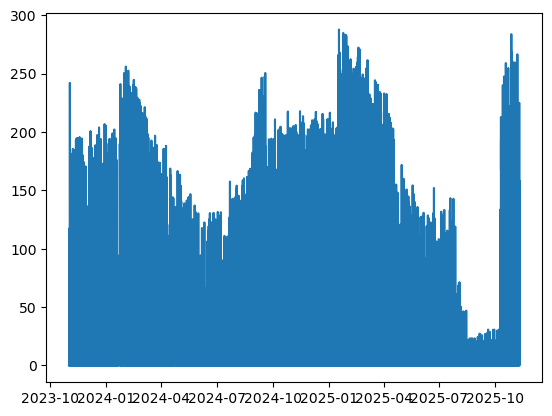

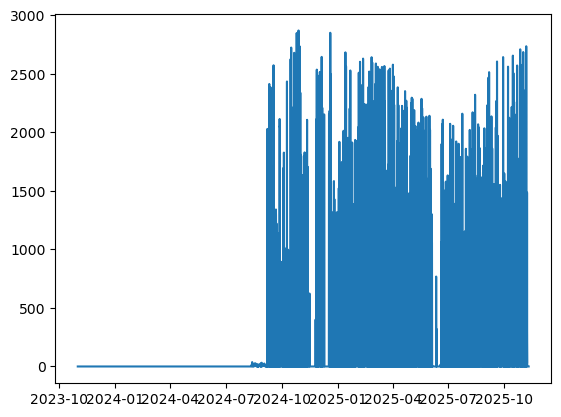

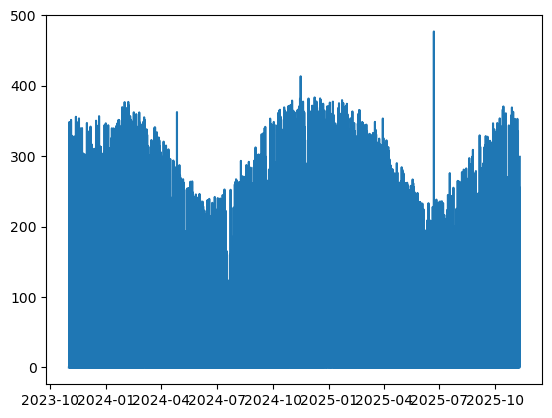

Saved: C:\Users\22390013@students.ltu.edu.au\OneDrive - LA TROBE UNIVERSITY\Projects\Solar\solar_forecast\LEAP_dev\data\combined_hourly.csv


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# === 1) Point to your three files ===
FILES = [
    {
        "path": "data/Bun_LTSS_PV_LGCMeter_Energy_Data.csv",
        "meter_id": "solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh",
    },
    {
        "path": "data/HV_Incoming_Energy_Data.csv",
        "meter_id": "solar.bun_hv_incoming#realenergyintotheload#kwh",      # <- change if needed
    },
    {
        "path": "data/Bendigo_LSU_Carpark_Energy_Data.csv",
        "meter_id": "solar.ben_carpark#realenergyintotheload#kwh" #"solar.ben_carpark#realenergyintotheload#kwh", # <- change if needed
    },
]


def to_hourly(file_path: str, meter_id: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, parse_dates=["Timestamp"])
    # strip/clean headers
    df.columns = [c.strip() for c in df.columns]

    ts_col = df.columns[0] #pick_timestamp_col(df.columns)
    val_col = df.columns[1] #pick_energy_col(df)

    hourly = df.resample("h", on=ts_col)[val_col].sum().rename("meter_reading").reset_index()

    # add meter id
    hourly["meter"] = meter_id

    # final columns in requested order
    hourly = hourly.rename(columns={ts_col: "timestamp"})
    hourly = hourly[["timestamp", "meter_reading", "meter"]]
    return hourly

# === 3) Build and save the combined hourly dataset ===
hourly_frames = [to_hourly(f["path"], f["meter_id"]) for f in FILES]
final_hourly = pd.concat(hourly_frames, ignore_index=True)#.sort_values("timestamp")

# format timestamp exactly like: DD/MM/YYYY HH:MM
final_hourly["timestamp"] = final_hourly["timestamp"].dt.strftime("%d/%m/%Y %H:%M")

out_path = Path("data/combined_hourly.csv")
final_hourly.to_csv(out_path, index=False)

df__ = final_hourly[final_hourly["meter"] == "solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh"]
df__ = final_hourly[final_hourly["meter"] == "solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh"]
print(final_hourly.head(10))
plt.plot(hourly_frames[0]["timestamp"], hourly_frames[0]["meter_reading"])
plt.show()
plt.plot(hourly_frames[1]["timestamp"], hourly_frames[1]["meter_reading"])
plt.show()
plt.plot(hourly_frames[2]["timestamp"], hourly_frames[2]["meter_reading"])
plt.show()

print(f"Saved: {out_path.resolve()}")


# Test Code

C:\Users\22390013@students.ltu.edu.au\AppData\Local\Temp\ipykernel_4636\2315981691.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_sum = df.resample("H", on="Timestamp")[col].sum().reset_index()


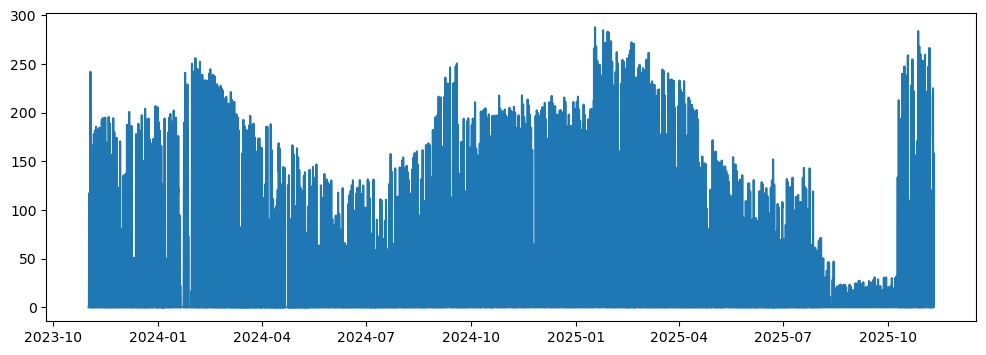

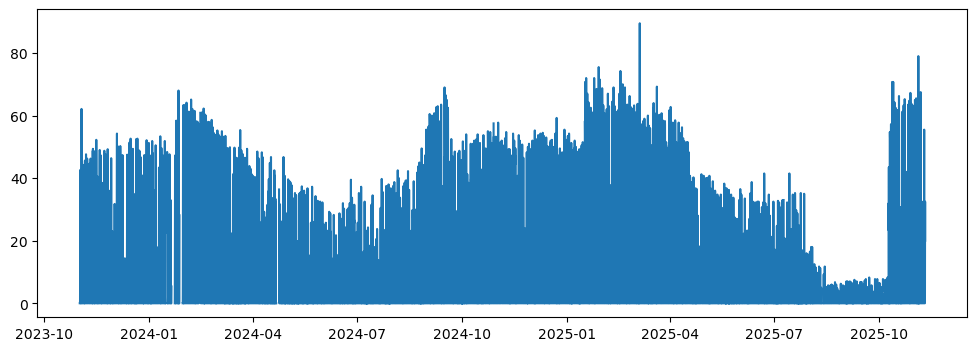

In [2]:
df = pd.read_csv(
    r"data\Bun_LTSS_PV_LGCMeter_Energy_Data.csv",  # or "data/Bun_LTSS_PV_LGCMeter_Energy_Data.csv"
    parse_dates=["Timestamp"]
)

col = "Solar.Bun_LTSS_PV_LGCMeter#Real Energy Into the Load#kWh"


# print(df.columns)
df_val = df[df["Timestamp"].dt.minute == 0]

df_sum = df.resample("H", on="Timestamp")[col].sum().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(
    df_sum["Timestamp"],
    df_sum["Solar.Bun_LTSS_PV_LGCMeter#Real Energy Into the Load#kWh"]
)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(
    df_val["Timestamp"],
    df_val["Solar.Bun_LTSS_PV_LGCMeter#Real Energy Into the Load#kWh"]
)
plt.show()